<a href="https://colab.research.google.com/github/Chackmilo/Transformer/blob/Transformer/Transfer_Learning_Netflix_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Curso Transfer Learning

<img src="https://yaelmanuel.com/wp-content/uploads/2021/12/platzi-banner-logo-matematicas.png" width="500px">

---

## Creando nuestro propio Clasificador de Imágenes 🐶🐷🍞

En este lab aprenderás:

* [Pytorch](https://pytorch.org/)
* [Torchvision](https://pytorch.org/vision/stable/index.html)
* Descargar un dataset, prepararlo, entrenarlo, realizar finetuning y guardarlo.


### 1) Descarga del dataset 🤓

Utilizaremos 2 conjuntos de imágenes de Kaggle:
- [Animal Image Dataset (90 Different Animals)](https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals)
- [Multi-class food image dataset](https://www.kaggle.com/datasets/liamboyd1/multi-class-food-image-dataset)

#### 1.1) Configurar Kaggle

In [ ]:
!pip install --upgrade --force-reinstall --no-deps kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105786 sha256=ebe6f546e1f81991b449fb1a57cf9a9f07b2073a0b95926cdc103ab2b122433d
  Stored in directory: /root/.cache/pip/wheels/ff/55/fb/b27a466be754d2a06ffe0e37b248d844f090a63b51becea85d
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.6.17
    Uninstalling kaggle-1.6.17:
      Successfully uninstalled kaggle-1.6.17


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"carlosbustillo","key":"dba71f9d5aea5f59899bb412d82f8559"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

#### 1.2) Imágenes de Perros y Cerdos

In [ ]:
!kaggle datasets download -d iamsouravbanerjee/animal-image-dataset-90-different-animals

Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals
License(s): other
 99% 651M/656M [00:08<00:00, 101MB/s] 
100% 656M/656M [00:08<00:00, 81.4MB/s]


In [ ]:
!unzip '/content/animal-image-dataset-90-different-animals.zip'

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: animals/animals/bison/73b10839bc.jpg  
  inflating: animals/animals/bison/74dc1dd32a.jpg  
  inflating: animals/animals/bison/75ab166a7d.jpg  
  inflating: animals/animals/bison/79e1610d01.jpg  
  inflating: animals/animals/bison/7ba5eee91f.jpg  
  inflating: animals/animals/bison/7d214aab4b.jpg  
  inflating: animals/animals/bison/7f2ef9ab03.jpg  
  inflating: animals/animals/bison/82ec723a4f.jpg  
  inflating: animals/animals/bison/85e145af6c.jpg  
  inflating: animals/animals/bison/862e2c6379.jpg  
  inflating: animals/animals/bison/87a5c700ad.jpg  
  inflating: animals/animals/bison/88b723ce90.jpg  
  inflating: animals/animals/bison/8c3af742c3.jpg  
  inflating: animals/animals/bison/8e34044b98.jpg  
  inflating: animals/animals/bison/8e6adbdc40.jpg  
  inflating: animals/animals/bison/8fce80d5ba.jpg  
  inflating: animals/animals/bison/961a895686.jpg  
  inflating: animals/animals/bison/984a5b583d.jpg  
  i

***Creamos un folder "peli_netflix" para guardar nuestras imágenes.***

In [ ]:
!mkdir /content/peli_netflix

***Tenemos una estructura de carpetas para "train" y "val".***

In [ ]:
!mkdir /content/peli_netflix/train
!mkdir /content/peli_netflix/val

***Movemos la carpeta de imágenes de cerdo y perro a "train" y "val"***

In [ ]:
!mv /content/animals/animals/pig /content/peli_netflix/train/pig
!mv /content/animals/animals/dog /content/peli_netflix/train/dog

Ahora movemos el 20% de "train" a "val"

In [ ]:
import os
import subprocess

# Lista de carpetas a procesar
folders = ["pig", "dog"]

for folder in folders:
    # Define las rutas de las carpetas de origen y destino
    train_dir = f"/content/peli_netflix/train/{folder}"
    val_dir = f"/content/peli_netflix/val/{folder}"

    # Crear la carpeta de destino si no existe
    os.makedirs(val_dir, exist_ok=True)

    # Contar los archivos en la carpeta de origen
    total_files = len(os.listdir(train_dir))
    num_files_to_move = total_files * 20 // 100  # Calcula el 20%

    if num_files_to_move > 0:
        # Seleccionar aleatoriamente el 20% de los archivos y moverlos
        command = f"ls {train_dir} | shuf | head -n {num_files_to_move} | xargs -I {{}} mv {train_dir}/{{}} {val_dir}/"
        subprocess.run(command, shell=True)
        print(f"Movidos {num_files_to_move} archivos de {train_dir} a {val_dir}")
    else:
        print(f"No hay suficientes archivos para mover en {train_dir}.")

Movidos 12 archivos de /content/peli_netflix/train/pig a /content/peli_netflix/val/pig
Movidos 12 archivos de /content/peli_netflix/train/dog a /content/peli_netflix/val/dog


***Removemos el resto de los archivos para ahorrar memoria***

In [ ]:
!rm -r "/content/name of the animals.txt"
!rm -r /content/animal-image-dataset-90-different-animals.zip
!rm -r /content/animals

#### 1.3) Imágenes de Rebanadas de pan

In [ ]:
!kaggle datasets download -d liamboyd1/multi-class-food-image-dataset

Dataset URL: https://www.kaggle.com/datasets/liamboyd1/multi-class-food-image-dataset
License(s): unknown
100% 329M/329M [00:03<00:00, 116MB/s] 
100% 329M/329M [00:03<00:00, 99.1MB/s]


In [ ]:
!unzip '/content/multi-class-food-image-dataset.zip'

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: val/carrots/carrots.203.jpg  
  inflating: val/carrots/carrots.204.jpg  
  inflating: val/carrots/carrots.205.jpg  
  inflating: val/carrots/carrots.206.jpg  
  inflating: val/carrots/carrots.207.jpg  
  inflating: val/carrots/carrots.208.jpg  
  inflating: val/carrots/carrots.209.jpg  
  inflating: val/carrots/carrots.21.jpg  
  inflating: val/carrots/carrots.210.jpg  
  inflating: val/carrots/carrots.211.jpg  
  inflating: val/carrots/carrots.212.jpg  
  inflating: val/carrots/carrots.213.jpg  
  inflating: val/carrots/carrots.214.jpg  
  inflating: val/carrots/carrots.215.jpg  
  inflating: val/carrots/carrots.216.jpg  
  inflating: val/carrots/carrots.217.jpg  
  inflating: val/carrots/carrots.218.jpg  
  inflating: val/carrots/carrots.219.jpg  
  inflating: val/carrots/carrots.22.jpg  
  inflating: val/carrots/carrots.220.jpg  
  inflating: val/carrots/carrots.221.jpg  
  inflating: val/carrots/carrots.222.j

***Movemos la carpeta de bread a nuestro "train" y "val".***

In [ ]:
!mv /content/train/bread /content/peli_netflix/train/bread
!mv /content/test/bread /content/peli_netflix/val/bread

***Removemos el resto de los archivos para ahorrar memoria***

In [ ]:
!rm -r /content/multi-class-food-image-dataset.zip
!rm -r /content/train
!rm -r /content/test
!rm -r /content/val

### 2) Preparación de la data 👌

#### 2.1) Instalamos las dependencias 🙌

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy

#### 2.2) Tips de implementación 👀

In [ ]:
cudnn.benchmark = True

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#### 2.3) Data Augmentation 📷 📸

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

#### 2.4) Dataset, Dataloader y más data 🔍

In [ ]:
!ls

56824d90-e61e-4d6a-9a8d-726612e8c6d7.jpg  kaggle.json  model.pth  peli_netflix	sample_data


In [ ]:
data_dir = 'peli_netflix'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=2) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = image_datasets['train'].classes

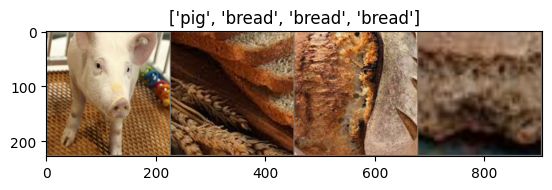

In [ ]:
def imshow(inp, title=None):
    """Imshow para tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # Pausarlo un poco para que se actualicen los plots


# Obtener un batch de datos de entrenamiento
inputs, classes = next(iter(dataloaders['train']))

# Crear una grilla con las imágenes
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

***Evaluar las class_names***

In [ ]:
print(class_names)

['bread', 'dog', 'pig']


### 3) Entrenamiento con Early Stopping 💪

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, patience=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    ### CAMBIO INICIADO ###
    epochs_no_improve = 0  # Contador para "early stopping"
    early_stop = False  # Flag para detener el entrenamiento
    ### CAMBIO FINAL ###

    for epoch in range(num_epochs):
        ### CAMBIO INICIADO ###
        if early_stop:  # Detener el entrenamiento si se activa "early stopping"
            print(f"Stopped early at epoch {epoch}/{num_epochs - 1}")
            break
        ### CAMBIO FINAL ###

        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Cada epoch tiene una fase de entrenamiento y validación.
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Fase entrenamiento
            else:
                model.eval()   # Fase validación

            running_loss = 0.0
            running_corrects = 0

            # Iterar sobre la data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize solo si es la fase de entrenamiento
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Estadísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            ### CAMBIO INICIADO ###
            # Guardar el mejor modelo basado en la precisión en validación
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0  # Reset paciencia si hay mejora
                else:
                    epochs_no_improve += 1  # Incrementa paciencia si no hay mejora

                # Detener el entrenamiento si no mejora en 'patience' épocas
                if epochs_no_improve >= patience:
                    print("Early stopping triggered!")
                    early_stop = True
                    break
            ### CAMBIO FINAL ###

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # Cargar los pesos del mejor modelo
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

### 4) Finetuning de la convnet 😨

In [ ]:
model_ft = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model_ft.fc.in_features

In [ ]:
# Aquí el tamaño de cada muestra de salida se establece en len(class_names) = 3.
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe que todos los parámetros están siendo optimizados
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decae LR por un factor de 0.1 cada 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

***Vamos a usar 10 epochs***

In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10, patience=3)

In [ ]:
visualize_model(model_ft)

### 5) Guardar el modelo 💾

In [ ]:
torch.save(model_ft, "model.pth")

### 6) Hacer Predicciones en Producción 🤙

In [ ]:
import torch
from torchvision import transforms
from PIL import Image

Cargar el modelo una vez (al inicio de la aplicación)

In [ ]:
# Determinar el dispositivo
mi_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar el modelo en el dispositivo
mi_modelo = torch.load("model.pth", map_location=mi_device, weights_only=False)
mi_modelo.eval()
mi_modelo.to(mi_device)

Función para predicción / inferencia

In [ ]:
def predict_image(image_path, model, class_names, device):
    """
    Predice la clase de una imagen usando un modelo entrenado.

    Args:
        image_path (str): Ruta de la imagen.
        model (torch.nn.Module): Modelo ya cargado y configurado para inferencia.
        class_names (list): Lista de nombres de clases.
        device (torch.device): Dispositivo donde está el modelo.

    Returns:
        str: Clase predicha.
    """
    # Preprocesamiento de la imagen
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Cargar y preprocesar la imagen
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(device)  # Añadir dimensión batch y mover al dispositivo

    # Realizar predicción
    with torch.no_grad():
        outputs = model(image_tensor)
        _, preds = torch.max(outputs, 1)

    # Retornar la clase predicha
    return class_names[preds[0].item()]

Ejemplos de uso

In [ ]:
# class_names = ['bread', 'dog', 'pig']
class_names = ['Rebanada de pan', 'Perro', 'Cerdo']

In [ ]:
path_image = "/content/peli_netflix/val/dog/7f45bd0030.jpg"

predicted_class = predict_image(path_image, mi_modelo, class_names, mi_device)
print(f"La clase predicha es: {predicted_class}")

In [ ]:
path_image = "/content/peli_netflix/val/pig/61cf5127ce.jpg"

predicted_class = predict_image(path_image, mi_modelo, class_names, mi_device)
print(f"La clase predicha es: {predicted_class}")

In [ ]:
path_image = "/content/peli_netflix/val/bread/bread.106.jpg"

predicted_class = predict_image(path_image, mi_modelo, class_names, mi_device)
print(f"La clase predicha es: {predicted_class}")

In [ ]:
path_image = "/content/56824d90-e61e-4d6a-9a8d-726612e8c6d7.jpg"

predicted_class = predict_image(path_image, mi_modelo, class_names, mi_device)
print(f"La clase predicha es: {predicted_class}")

### 7) Conclusiones

- Aprender sobre los distintos objetos y métodos que nos ofrece Pytorch / Torchvision.

- Realizar el proceso completo de clasificación de imágenes con Pytorch.

- Aprender tips sobre implementación con el uso de la GPU.

<br>
<br>
<br>

---

<br>
<br>


<img src="https://static.platzi.com/media/avatars/platziteam_8cfe6fc7-1246-4c9a-9f5d-d10d467443ee.png" width="100px">

[Platzi](https://platzi.com/) 🚀

